In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 6.1 MB/s eta 0:00:00


In [ ]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
query = "select * from heartdb"

In [ ]:
con = snowflake.connector.connect(
    user = "Alaguraja",
    password = "Alagurajakannan@787",
    account = "DXMKEOQ-ON75318",
    database = "heart",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [ ]:
df = pd.read_sql(query, con)

/tmp/ipykernel_2211/1914986641.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


In [ ]:
df

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   AGE       303 non-null    int64  
 1   SEX       303 non-null    int64  
 2   CP        303 non-null    int64  
 3   TRESTBPS  303 non-null    int64  
 4   CHOL      303 non-null    int64  
 5   FBS       303 non-null    int64  
 6   RESTECG   303 non-null    int64  
 7   THALACH   303 non-null    int64  
 8   EXANG     303 non-null    int64  
 9   OLDPEAK   303 non-null    float64
 10  SLOPE     303 non-null    int64  
 11  CA        303 non-null    int64  
 12  THAL      303 non-null    int64  
 13  TARGET    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.describe()

,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


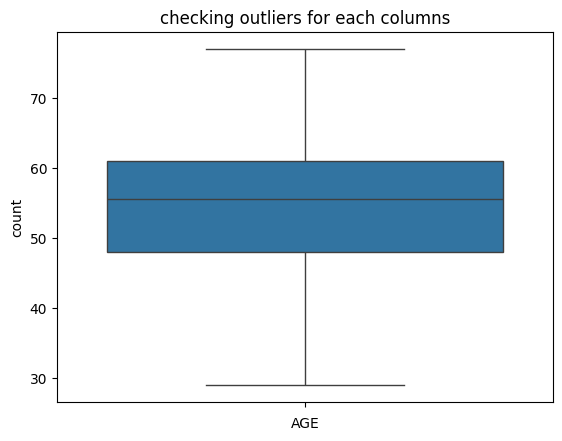

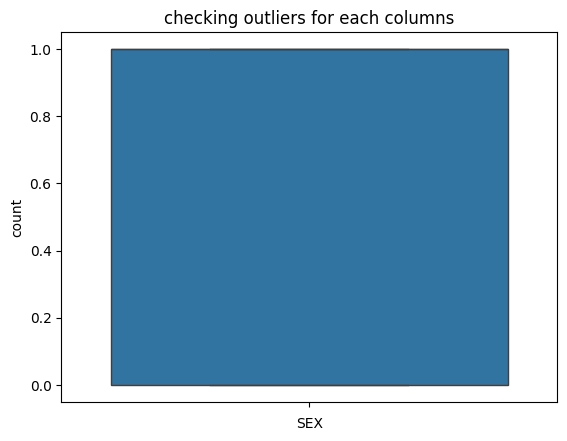

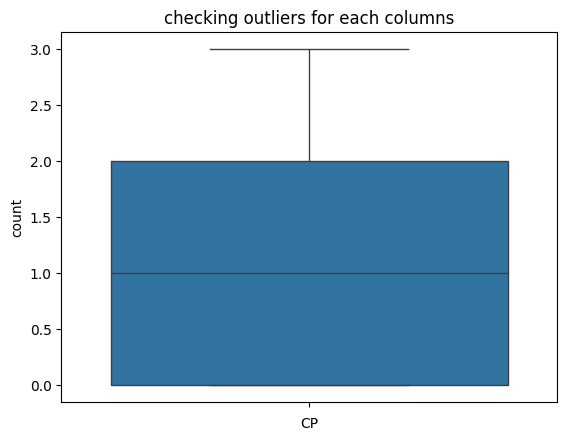

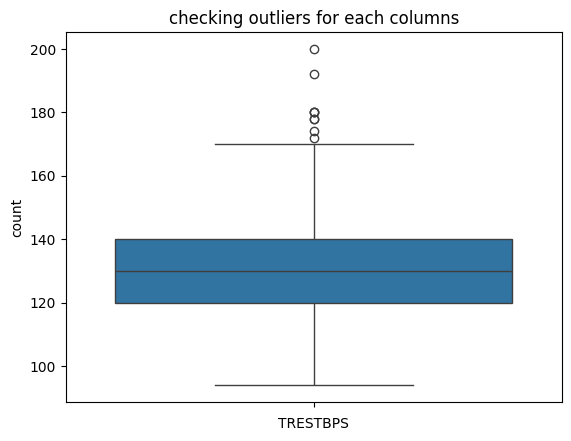

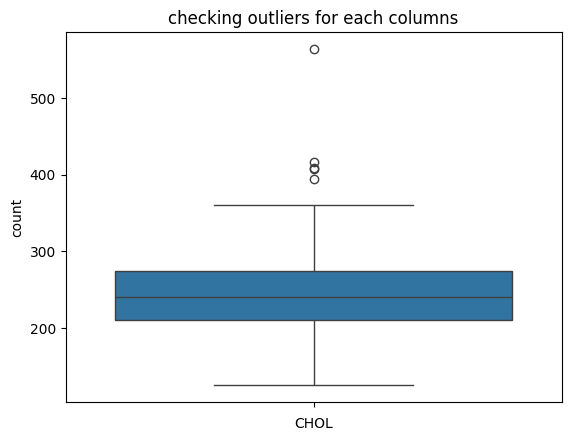

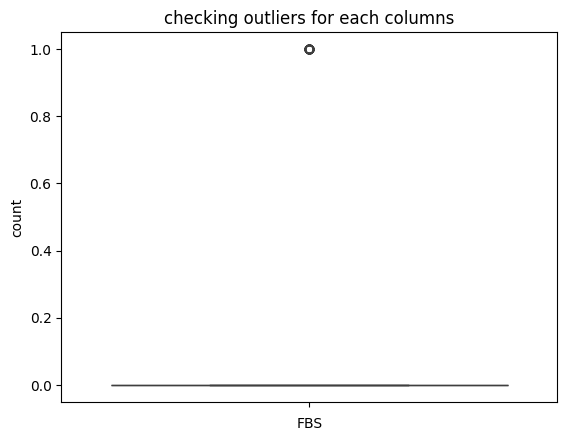

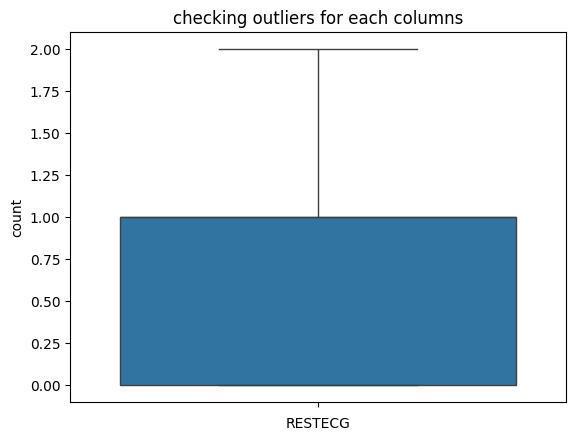

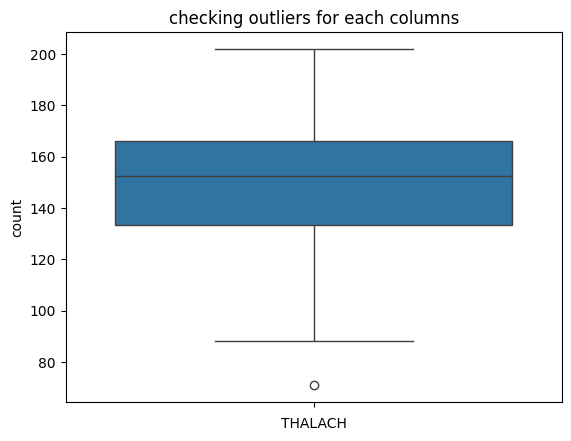

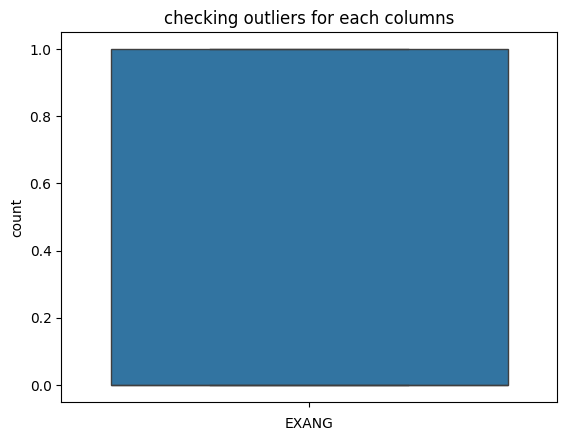

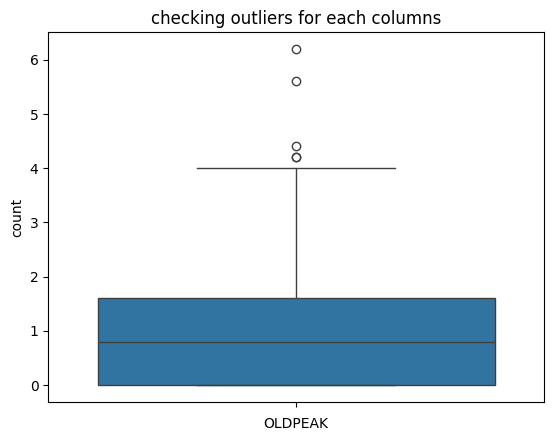

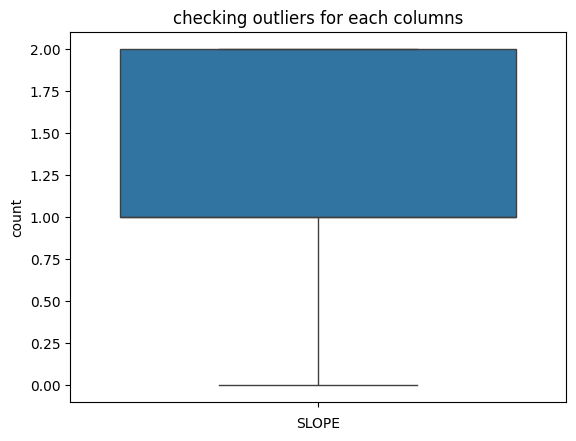

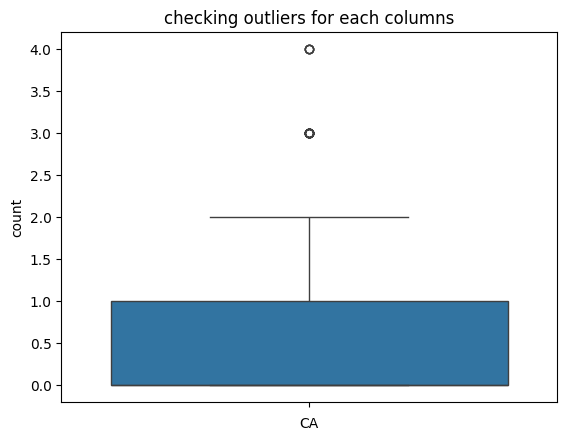

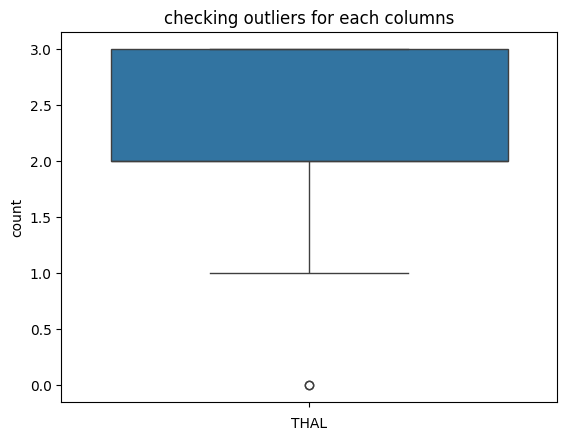

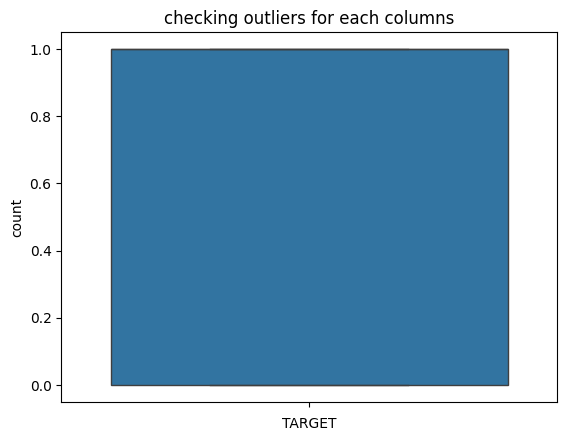

In [ ]:
for i in df.columns:
  if df[i].dtypes != "object":
    sns.boxplot(df[i])
    plt.title("checking outliers for each columns")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
for i in df.columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr
  df = df[(lower_fence <= df[i]) & (upper_fence >= df[i])]

In [ ]:
df["TARGET"].unique()

array([1, 0])

In [ ]:
x = df.iloc[:,:-1]
y = df["TARGET"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(x_train, y_train)
y_pred = model1.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 0.8043478260869565


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier(criterion = "entropy")
model2.fit(x_train, y_train)
y_pred = model2.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 84.78260869565217


In [ ]:
from sklearn.naive_bayes import BernoulliNB
model3 = BernoulliNB()
model3.fit(x_train, y_train)
y_pred = model3.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 78.26086956521739


In [ ]:
from sklearn.svm import SVC
model4 = SVC(kernel = "rbf")
model4.fit(x_train, y_train)
y_pred = model4.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 56.52173913043478


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model5 = KNeighborsClassifier(n_neighbors = 3)
model5.fit(x_train, y_train)
y_pred = model5.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 63.04347826086957


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [ ]:
params = {
    "max_depth" : [10,11,12,13,14,15,16,17,20,25],
    "n_jobs" : [-1,1,3,4],
    "min_samples_split" : [4,3,6,5],
    "min_samples_leaf" : [1,2,3,4,5],
    "class_weight" : ["balanced"],
}

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    model, param_grid = params, cv = 5, scoring = "accuracy"
)

In [ ]:
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [10, 11, 12, 13, 14, 15, 16, 17, 20, 25],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [4, 3, 6, 5],
                         'n_jobs': [-1, 1, 3, 4]},
             scoring='accuracy')

In [ ]:
grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 14,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_jobs': 4}

In [ ]:
best_model = grid.best_estimator_

In [ ]:
y_pred = best_model.predict(x_test)

In [ ]:
print("accuracy_score of my model:", accuracy_score(y_test, y_pred))

accuracy_score of my model: 0.7608695652173914
